This script shows how to run an LES model

This notebook does:

1. Load IC of `w(x,y)` from a NetCDF file (variable name: `w`).
2. Run one of the following LES models: NGM4, SIM, DM, DSMAG. 
3. Save that run.

In [1]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [3]:
# ----------------------------
# User knobs
# ----------------------------
# Input: NetCDF containing vorticity variable `w` on a periodic 2pi box
INP = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/IC.nc")

# Output: Where to save
OUT_DIR = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Make output directory
OUT_PATH = OUT_DIR / "LES.nc"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

n_les = 128                                # Resolution of LES
Delta = 6 *jnp.pi / n_les                  # Delta of LES, highly recommended to NOT change this
TOTAL_TIME = 1.0                           # total simulated time
SAVE_EVERY = 0.1                           # save cadence (in simulation time units)

SMOOTH = True                              # spectral dealiasing / smoothing toggle (JAX-CFD)
CFL = 0.3                                  # CFL used for dt estimate (advection)

ds = xr.open_dataset(INP)
if "w" not in ds:
    raise KeyError(f"Expected variable 'w' in {INP}, found: {list(ds.data_vars)}")
    
nu = float(ds.attrs["nu"])                 # kinematic viscosity, change if wanted
drag = float(ds.attrs["drag"])             # drag, change if wanted
kf = float(ds.attrs["kf"])                 # forcing frequency, change if wanted
amp = float(ds.attrs["amp"])               # forcing amplitude, change if wanted

alpha = 2                                  # sets the second filter scale, only relevant for DM and SMAG

if ds.attrs["nu"] != None:
    forcing_exists = True
else:
    forcing_exists = False

Loaded w0 with shape (Nx, Ny) = (512, 512)


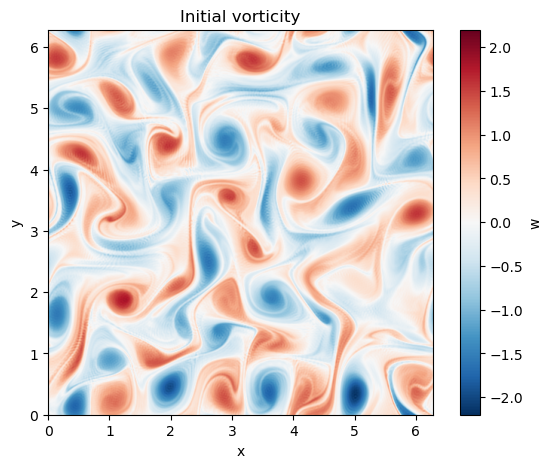

In [4]:
# ----------------------------
# Load initial vorticity
# ----------------------------
w0 = jnp.asarray(ds["w"].values)
if w0.ndim != 2:
    raise ValueError(f"Expected 2D vorticity field, got shape {w0.shape}")

Nx, Ny = w0.shape
print(f"Loaded w0 with shape (Nx, Ny) = {w0.shape}")

# Quick look
plt.figure(figsize=(7, 5))
vmax = np.max(np.abs(w0))
plt.imshow(w0, origin="lower", cmap="RdBu_r",extent=[0, 2*np.pi, 0, 2*np.pi], vmin=-vmax, vmax=vmax)
plt.colorbar(label="w")
plt.title("Initial vorticity")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [5]:
# ----------------------------
# Create some stuff that is needed
# ----------------------------

import jax_cfd.spectral.subgrid_models as subgrid_models
grid_dns = grids.Grid(shape=(Nx,Ny), domain=((0, 2*np.pi), (0, 2*np.pi)))
grid = grids.Grid(shape=(n_les,n_les), domain=((0, 2*np.pi), (0, 2*np.pi)))

if forcing_exists == True:
    forcing_fn = lambda grid: spectral.forcings.checkerboard_forcing_module(grid, freq=kf, amp=amp)
else:
    forcing_fn = None

w_to_v = spectral.utils.vorticity_to_velocity(grid)
w_to_v_dns = spectral.utils.vorticity_to_velocity(grid_dns)
fourier_filter = spectral.utils.get_filter_fn(Delta=Delta,grid=grid)
def vmax(w_hat):
    u_hat = jnp.stack(w_to_v_dns(w_hat),axis=-1)
    u = jnp.fft.irfft2(u_hat,axes=(0,1))**2
    u_mag = jnp.sqrt(jnp.sum(u,axis=-1))
    return u_mag.max()
w_hat = jnp.fft.rfft2(w0)
v_rms = vmax(w_hat)
dt = cfd.equations.stable_time_step(v_rms, .3, nu, grid, implicit_diffusion=True)

In [6]:
# ----------------------------
# Here you can choose which model to run
# ----------------------------

#For Similarity use the following:
#model = subgrid_models.similarity(nu,grid,Delta,smooth=True,drag=drag,k_filter=2/3,forcing_fn=forcing_fn)

#For NGM4 use the following:
#model = subgrid_models.NGM4(nu,grid,Delta,smooth=True,drag=drag,k_filter=2/3,forcing_fn=forcing_fn)

#For DM use the following:
#model = subgrid_models.Dynamic_Mixed(nu,grid,Delta,alpha = alpha,smooth=True,drag=drag,k_filter=2/3,forcing_fn=forcing_fn)

#For DSMAG use the following:
model = subgrid_models.Dynamic_Smagorinsky(nu,grid,Delta,alpha = alpha, smooth=True,drag=drag,k_filter=2/3,forcing_fn=forcing_fn)

In [7]:
# ----------------------------
# This runs the integrator
# ----------------------------

dt_est = float(dt)
inner_steps = int(np.ceil(SAVE_EVERY / dt_est))
inner_steps = max(inner_steps, 1)
dt = SAVE_EVERY / inner_steps
dt = float(dt)

# Choose outer_steps so you save about TOTAL_TIME / SAVE_EVERY frames
outer_steps = int(np.round(TOTAL_TIME / SAVE_EVERY))
outer_steps = max(outer_steps, 1)

t_final = outer_steps * SAVE_EVERY
if abs(t_final - TOTAL_TIME) > 1e-12:
    print(f"[Note] TOTAL_TIME={TOTAL_TIME} is not an integer multiple of SAVE_EVERY={SAVE_EVERY}.")
    print(f"       Will run to t_final={t_final} (outer_steps={outer_steps}).")

print(f"dt_est={dt_est:.6e}  -> inner_steps={inner_steps}, dt={dt:.6e} (dt*inner_steps={dt*inner_steps:.6e})")
print(f"outer_steps={outer_steps}, saved frames={outer_steps}, final saved time={t_final:.6e}")

# ---- trajectory ----
step_fn = spectral.time_stepping.crank_nicolson_rk4(model, dt)
trajectory_fn = cfd.funcutils.trajectory(cfd.funcutils.repeated(step_fn, inner_steps),outer_steps)

u = jnp.stack(spectral.utils.vorticity_to_velocity(grid_dns)(w_hat), axis=-1)
u_les = spectral.utils.down_res(u, [n_les, n_les])
u_les = fourier_filter(u_les)
state = (u_les)

out = trajectory_fn(state)
if isinstance(out, tuple) and len(out) == 2:
    _, traj_out = out
else:
    traj_out = out

u_hat = traj_out[..., 0]
v_hat = traj_out[..., 1]

# vmap the existing function directly
w_hat_traj = jax.vmap(
    lambda uh, vh: spectral.utils.spectral_curl_2d(grid, (uh, vh))
)(u_hat, v_hat)

# back to real space
w_traj = jnp.fft.irfft2(w_hat_traj, axes=(1, 2))

dt_est=5.223359e-02  -> inner_steps=2, dt=5.000000e-02 (dt*inner_steps=1.000000e-01)
outer_steps=10, saved frames=10, final saved time=1.000000e+00


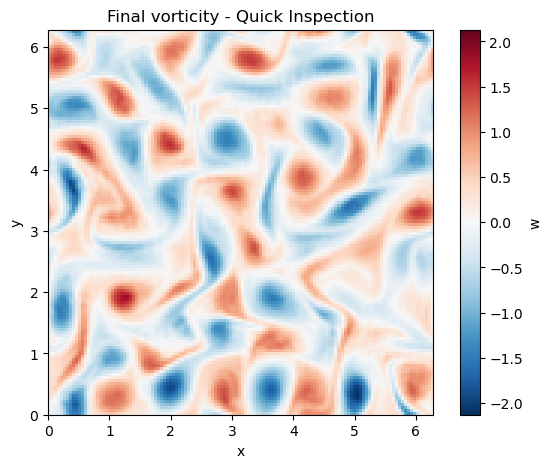

In [8]:
# ----------------------------
# Check that the last timestep is fine
# ----------------------------

plt.figure(figsize=(7, 5))
vmax = np.max(np.abs(w_traj[-1,:,:]))
plt.imshow(w_traj[-1,:,:], origin="lower", cmap="RdBu_r",extent=[0, 2*np.pi, 0, 2*np.pi], vmin=-vmax, vmax=vmax)
plt.colorbar(label="w")
plt.title("Final vorticity - Quick Inspection")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [9]:
# ------------------------------------------------------------
# SAVE: real-space trajectory w(time,y,x) 
# ------------------------------------------------------------

# Build time array (include t=0 frame if traj_out includes it)
t_np = np.arange(outer_steps, dtype=np.float64) * SAVE_EVERY

# Coordinates for periodic 2π box
x = np.linspace(0.0, 2*np.pi, n_les, endpoint=False)
y = np.linspace(0.0, 2*np.pi, n_les, endpoint=False)

forcing_name = "checkerboard" if forcing_exists else "none"

# NetCDF attrs can't store numpy/jax bools reliably -> use int or string
attrs = {
    "total_time": float(TOTAL_TIME),
    "save_every": float(SAVE_EVERY),
    "Delta": float(Delta),
    "nu": float(nu),
    "drag": float(drag),
    "smooth": int(bool(SMOOTH)),
    "cfl": float(CFL),
    "use_forcing": int(bool(forcing_exists)),
    "forcing": forcing_name,
    "kf": float(kf),
    "amp": float(amp),
    "alpha": float(alpha),
}

# Make sure dims match your array layout: w_traj_np is (time, x, y) or (time, y, x)?
# irfftn over axes (1,2) on traj_out typically gives (time, Nx, Ny) if traj_out is (time, Nx, Nyh)
# So map it consistently:
ds_out = xr.Dataset(
    data_vars={"w": (("time", "x", "y"), w_traj)},
    coords={"time": t_np, "x": x, "y": y},
    attrs=attrs,
)

stem = Path(INP).stem
out_path = OUT_PATH

encoding = {"w": {"zlib": True, "complevel": 4, "dtype": "float32"}}

ds_out.to_netcdf(out_path, encoding=encoding)

print("Saved:", out_path)
print("w shape:", w_traj.shape, "frames:", len(t_np))

Saved: /storage/home/hcoda1/4/mugliotti3/scratch/temporary/LES.nc
w shape: (10, 128, 128) frames: 10
